# Nebular Emission Gallery

_nebular_gallery

Visual catalogue aligned with the model-track notebook: **nebular** backends
(CLOUDY-style ratios, Cue when weights exist), **shocks**, **DIG** mixing, $Q_H$,
plus **IGM** and **spectroscopy** utilities (LSF, calibration, line design matrix).
For **emission-line marginalization** in fits, see `08_fitting_spectra.py`.

**Paper §3:** nebular emission sits **after** the CSP integral and **before** dust in the full chain.

In [ ]:
import importlib.util
import os
import sys
import warnings
from pathlib import Path

try:
    _nb_dir = os.path.dirname(os.path.abspath(__file__))
    _repo_root = os.path.abspath(os.path.join(_nb_dir, ".."))
except NameError:
    _nb_dir = os.getcwd()
    _repo_root = os.path.abspath(os.path.join(_nb_dir, ".."))

_src = os.path.join(_repo_root, "src")
if os.path.isdir(os.path.join(_src, "tengri")):
    sys.path.insert(0, _src)
sys.path.insert(0, _repo_root)
sys.path.insert(0, _nb_dir)

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", category=FutureWarning)

from tengri import Fixed, SEDModel, Parameters, load_ssp_data
from tengri.models.igm import igm_transmission, igm_transmission_patchy
from tengri.models.nebular.shock import shock_line_ratios
from tengri.models.observation.calibration import (
    calibration_polynomial,
    chebyshev_basis,
)
from tengri.models.observation.eline_catalog import (
    CLOUDY_LINE_NAMES,
    CLOUDY_LINE_WAVELENGTHS,
)
from tengri.models.observation.eline_marginalization import (
    DEFAULT_LINE_NAMES,
    DEFAULT_LINE_WAVELENGTHS,
    build_eline_design_matrix,
)
from tengri.models.observation.spectrum import (
    apply_lsf,
    nirspec_prism_resolution,
)

_nbooks = os.path.join(_repo_root, "notebooks")
if os.path.isdir(_nbooks):
    sys.path.insert(0, _nbooks)

_repo_data_root = None
_spec_tengri = importlib.util.find_spec("tengri")
if _spec_tengri is not None and _spec_tengri.origin:
    _walk = os.path.dirname(os.path.abspath(_spec_tengri.origin))
    for _step in range(12):
        _candidate = os.path.join(_walk, "notebooks", "_plot_style.py")
        if os.path.isfile(_candidate):
            sys.path.insert(0, os.path.dirname(_candidate))
            _repo_data_root = os.path.dirname(os.path.dirname(os.path.abspath(_candidate)))
            break
        _parent_walk = os.path.dirname(_walk)
        if _parent_walk == _walk:
            break
        _walk = _parent_walk

if _repo_data_root is None:
    _np_here = os.path.abspath(os.getcwd())
    while True:
        if os.path.isfile(os.path.join(_np_here, "_plot_style.py")):
            sys.path.insert(0, _np_here)
            _repo_data_root = os.path.dirname(_np_here)
            break
        _ppt = os.path.join(_np_here, "notebooks", "_plot_style.py")
        if os.path.isfile(_ppt):
            _nbsd = os.path.dirname(_ppt)
            sys.path.insert(0, _nbsd)
            _repo_data_root = os.path.dirname(_nbsd)
            break
        _parent_here = os.path.dirname(_np_here)
        if _parent_here == _np_here:
            break
        _np_here = _parent_here

if _repo_data_root is not None and os.path.isdir(os.path.join(_repo_data_root, "data")):
    os.chdir(_repo_data_root)
elif os.path.isdir(os.path.join(_repo_root, "data")):
    os.chdir(_repo_root)
elif os.path.isdir("data"):
    pass
elif os.path.isdir(os.path.join("..", "data")):
    os.chdir("..")

try:
    from _plot_style import COLORS, setup_style
except ModuleNotFoundError:
    from tengri.plotting import setup_style

    COLORS = {
        "rt": "C0",
        "geovi": "C1",
        "nuts": "C2",
        "model": "C3",
        "seq": ["C0", "C1", "C2", "C3", "C4"],
    }

setup_style()

FIGDIR = os.path.join("notebooks", "figures", "nebular_gallery")
os.makedirs(FIGDIR, exist_ok=True)

CUE_WEIGHTS_PATH = Path("data/cue_weights.npz")

## Backend Decision Table

| Backend | Free params | Use when | Limitation |
|---------|-------------|----------|------------|
| `BakedIn` | 0 | Photometric fitting; logU fixed | logU/metallicity hardcoded |
| `CloudyGrid` | 3 (logU, Z, n_H) | Spectroscopy with ionization variation | Grid interpolation only |
| `Cue` | 12 | Abundance ratios (N/O, C/O) or non-stellar ionizing sources | Requires CUE install |

**Rule**: Use BakedIn for photometry. CloudyGrid for standard spectroscopy. Cue when
you need [N/O], [C/O], or AGN/shock ionizing spectrum shapes.

## 1. Nebular Emission

### 1.1 CLOUDY Grid: line ratios vs log(U)

The CLOUDY grid (Byler+2017) tabulates nebular emission as a function of
the ionization parameter $\log U$ and gas-phase metallicity. We show how
the major optical line ratios change with $\log U$ at solar metallicity.

Since loading the actual CLOUDY HDF5 grid requires the data file, we
illustrate the physics using standard photoionization model scaling
relations (Kewley+2001, Dopita+2013).

In [1]:
# Standard CLOUDY-like line ratio trends vs logU (solar metallicity)
# These are representative values from Byler+2017 / Kewley+2001 models.
logU_grid = np.linspace(-4.0, -1.5, 50)

# [OIII]5007/Hbeta: rises strongly with logU
r_oiii_hb = 10.0 ** (1.5 * (logU_grid + 3.0) - 0.3)
r_oiii_hb = np.clip(r_oiii_hb, 0.01, 20.0)

# [NII]6583/Halpha: relatively flat with logU, sensitive to metallicity
r_nii_ha = 0.4 * np.ones_like(logU_grid) + 0.05 * (logU_grid + 3.0)
r_nii_ha = np.clip(r_nii_ha, 0.05, 1.5)

# [OII]3727/Hbeta: peaks at intermediate logU
r_oii_hb = 3.0 * np.exp(-0.5 * ((logU_grid + 2.8) / 0.5) ** 2) + 0.5
r_oii_hb = np.clip(r_oii_hb, 0.1, 5.0)

# [SII]6717+6731/Halpha: decreases with logU
r_sii_ha = 0.5 * 10.0 ** (-0.4 * (logU_grid + 3.0))
r_sii_ha = np.clip(r_sii_ha, 0.05, 2.0)

# Halpha/Hbeta (Case B -- nearly constant)
r_ha_hb = 2.86 * np.ones_like(logU_grid)

fig, axes = plt.subplots(2, 3, figsize=(11, 5.5))

# Panel 1: [OIII]/Hbeta
ax = axes[0, 0]
ax.semilogy(logU_grid, r_oiii_hb, color=COLORS["seq"][2], lw=2)
ax.set_xlabel(r"$\log U$")
ax.set_ylabel(r"[OIII]5007 / H$\beta$")
ax.set_title(r"[OIII] / H$\beta$")

# Panel 2: [NII]/Halpha
ax = axes[0, 1]
ax.semilogy(logU_grid, r_nii_ha, color=COLORS["seq"][3], lw=2)
ax.set_xlabel(r"$\log U$")
ax.set_ylabel(r"[NII]6583 / H$\alpha$")
ax.set_title(r"[NII] / H$\alpha$")

# Panel 3: [OII]/Hbeta
ax = axes[0, 2]
ax.semilogy(logU_grid, r_oii_hb, color=COLORS["seq"][4], lw=2)
ax.set_xlabel(r"$\log U$")
ax.set_ylabel(r"[OII]3727 / H$\beta$")
ax.set_title(r"[OII] / H$\beta$")

# Panel 4: [SII]/Halpha
ax = axes[1, 0]
ax.semilogy(logU_grid, r_sii_ha, color=COLORS["rt"], lw=2)
ax.set_xlabel(r"$\log U$")
ax.set_ylabel(r"[SII] / H$\alpha$")
ax.set_title(r"[SII] / H$\alpha$")

# Panel 5: Halpha/Hbeta (Balmer decrement)
ax = axes[1, 1]
ax.plot(logU_grid, r_ha_hb, color=COLORS["vi"], lw=2)
ax.set_xlabel(r"$\log U$")
ax.set_ylabel(r"H$\alpha$ / H$\beta$")
ax.set_title(r"Balmer decrement (Case B $\approx 2.86$)")
ax.set_ylim(2.5, 3.5)

# Panel 6: BPT-like diagnostic (log [NII]/Ha vs log [OIII]/Hb)
ax = axes[1, 2]
# Parametric curve varying logU
x_bpt = np.log10(r_nii_ha)
y_bpt = np.log10(r_oiii_hb)
sc = ax.scatter(x_bpt, y_bpt, c=logU_grid, cmap="viridis", s=15, zorder=3)
ax.plot(x_bpt, y_bpt, color="grey", lw=0.5, alpha=0.5)
plt.colorbar(sc, ax=ax, label=r"$\log U$")
ax.set_xlabel(r"$\log$ [NII] / H$\alpha$")
ax.set_ylabel(r"$\log$ [OIII] / H$\beta$")
ax.set_title("BPT diagram (solar Z, varying logU)")

fig.suptitle("CLOUDY-like Line Ratios vs Ionization Parameter", y=1.01, fontsize=12)
fig.tight_layout()
# plt.savefig(os.path.join(FIGDIR, "19_cloudy_line_ratios.png"), bbox_inches="tight")
plt.show()

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'data/ssp_dsps_coelho_solmet.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

### 1.2 Cue Neural Emulator: N/O, C/O, and Ionizing Spectrum

The Cue emulator (Li+2025) adds 12 parameters over the CLOUDY grid:
7 ionizing spectrum shape coefficients + 5 gas properties
(`gas_logu`, `gas_logn`, `gas_logz`, `gas_logno`, `gas_logco`).

The three unique capabilities of Cue over the CLOUDY grid are:
- **[N/O]** (`gas_logno`): shifts [NII]/Hα independently of metallicity
- **[C/O]** (`gas_logco`): controls UV carbon lines (CIII]1909, CIV1549)
- **Ionizing spectrum shape**: handles AGN/shock ionization vs stellar

In [ ]:
if CUE_WEIGHTS_PATH.exists():
    from tengri.models.nebular.cue import (
        load_cue_weights,
        predict_all_lines,
        prepare_nn_params_from_dict,
    )

    weights = load_cue_weights(str(CUE_WEIGHTS_PATH))
    gas_logqion = 49.1  # typical log10(Q_H) normalization [photons/s/Msun]

    # Base parameters: stellar ionizing spectrum, solar metallicity
    _base = {
        "ionspec_index1": -1.0,
        "ionspec_index2": -1.5,
        "ionspec_index3": -2.0,
        "ionspec_index4": -2.5,
        "ionspec_logLratio1": 0.0,
        "ionspec_logLratio2": -0.5,
        "ionspec_logLratio3": -1.0,
        "gas_logu": -3.0,
        "gas_logn": 2.0,
        "gas_logz": 0.0,
        "gas_logno": -0.5,
        "gas_logco": -0.3,
    }

    def _line_ratio(params, wav1, wav2):
        """Return L(wav1) / L(wav2) from Cue at given params."""
        nn_p = prepare_nn_params_from_dict(params)
        gas_logq = float(nn_p[7])
        wav_arr, lum_arr = predict_all_lines(nn_p, weights, gas_logq, gas_logqion)
        wav_np = np.array(wav_arr)
        lum_np = np.maximum(np.array(lum_arr), 1e-40)
        i1 = int(np.argmin(np.abs(wav_np - wav1)))
        i2 = int(np.argmin(np.abs(wav_np - wav2)))
        return float(lum_np[i1]) / float(lum_np[i2])

    # Panel 1: N/O effect — sweep gas_logno, track [NII]6583/Hα
    logno_grid = np.linspace(-1.5, 0.5, 18)
    nii_ha = [_line_ratio({**_base, "gas_logno": float(v)}, 6583.0, 6563.0) for v in logno_grid]

    # Panel 2: C/O effect — sweep gas_logco, track CIII]1909/Hβ
    logco_grid = np.linspace(-1.0, 0.5, 18)
    ciii_hb = [_line_ratio({**_base, "gas_logco": float(v)}, 1909.0, 4861.0) for v in logco_grid]

    # Panel 3: Ionizing spectrum shape → BPT position (log [OIII]/Hβ vs log [NII]/Hα)
    ionspec_configs = {
        "Stellar (O-star)": {
            "ionspec_index1": -1.0,
            "ionspec_index2": -1.5,
            "ionspec_index3": -2.0,
            "ionspec_index4": -2.5,
            "ionspec_logLratio1": 0.0,
            "ionspec_logLratio2": -0.5,
            "ionspec_logLratio3": -1.0,
        },
        "AGN-like (flat)": {
            "ionspec_index1": -0.5,
            "ionspec_index2": -0.5,
            "ionspec_index3": -0.5,
            "ionspec_index4": -0.5,
            "ionspec_logLratio1": 0.0,
            "ionspec_logLratio2": 0.0,
            "ionspec_logLratio3": 0.0,
        },
        "Soft (cool star)": {
            "ionspec_index1": -2.5,
            "ionspec_index2": -3.0,
            "ionspec_index3": -3.5,
            "ionspec_index4": -4.0,
            "ionspec_logLratio1": 0.0,
            "ionspec_logLratio2": -1.0,
            "ionspec_logLratio3": -2.0,
        },
    }
    ionspec_markers = ["o", "s", "^"]
    ionspec_colors = [COLORS["rt"], COLORS["vi"], COLORS.get("mcmc_nuts", "#888888")]

    bpt_nii_ha = {}
    bpt_oiii_hb = {}
    for name, ionspec in ionspec_configs.items():
        p = {**_base, **ionspec}
        bpt_nii_ha[name] = _line_ratio(p, 6583.0, 6563.0)
        bpt_oiii_hb[name] = _line_ratio(p, 5007.0, 4861.0)

    # --- FIGURE: 3-panel Cue parameter sweeps ---
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))

    axes[0].plot(logno_grid, nii_ha, color=COLORS["rt"], lw=2.0)
    axes[0].set_xlabel("[N/O] = log(N/O)", fontsize=9)
    axes[0].set_ylabel(r"[NII]6583 / H$\alpha$", fontsize=9)
    axes[0].set_title(r"N/O effect on [NII]/H$\alpha$")

    axes[1].plot(logco_grid, ciii_hb, color=COLORS["vi"], lw=2.0)
    axes[1].set_xlabel("[C/O] = log(C/O)", fontsize=9)
    axes[1].set_ylabel(r"[CIII]1909 / H$\beta$", fontsize=9)
    axes[1].set_title(r"C/O effect on [CIII]1909/H$\beta$")

    for name, col, mk in zip(ionspec_configs, ionspec_colors, ionspec_markers):
        axes[2].scatter(
            np.log10(bpt_nii_ha[name]),
            np.log10(bpt_oiii_hb[name]),
            s=130,
            color=col,
            marker=mk,
            label=name,
            zorder=5,
        )
    axes[2].set_xlabel(r"log [NII]6583 / H$\alpha$", fontsize=9)
    axes[2].set_ylabel(r"log [OIII]5007 / H$\beta$", fontsize=9)
    axes[2].set_title("Ionizing spectrum → BPT position")
    axes[2].legend(fontsize=7.5, frameon=False)

    fig.suptitle("Cue Neural Emulator: Unique Capabilities vs CLOUDY Grid", y=1.01)
    fig.tight_layout()
    # plt.savefig(os.path.join(FIGDIR, "19_cue_parameter_sweeps.png"), bbox_inches="tight")
    plt.show()
else:
    print(f"Cue weights not found at: {CUE_WEIGHTS_PATH}")
    print("Generate with: python scripts/convert_cue_weights.py")
    print()
    print("Cue adds 12 parameters over the CLOUDY grid:")
    print("  gas_logno  ([N/O]): shifts [NII]/Hα independently of metallicity")
    print("  gas_logco  ([C/O]): controls UV carbon lines (CIII]1909, CIV1549)")
    print("  ionspec_index1..4: AGN/shock vs stellar ionizing spectrum shape")

### 1.3 Shock Emission: line ratios vs velocity

The MAPPINGS V shock model (Allen+2008) produces enhanced low-ionization
lines at moderate velocities. This distinguishes shock-heated gas from
HII region emission on BPT diagrams.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

# Compute line ratios via public API across a velocity grid
_shock_velocities = [100.0, 150.0, 200.0, 300.0, 400.0, 500.0, 750.0, 1000.0]
_shock_grid = [shock_line_ratios(v) for v in _shock_velocities]

velocities = np.array(_shock_velocities)
_r_oiii = np.array([r["O3_5007A"] for r in _shock_grid])
_r_nii = np.array([r["NII_6583A"] for r in _shock_grid])
_r_sii = np.array([r["SII_6716A"] + r["SII_6731A"] for r in _shock_grid])
_r_oii = np.array([r["OII_3726A"] + r["OII_3729A"] for r in _shock_grid])
_r_oi = np.array([r["OI_6300A"] for r in _shock_grid])
_r_ha = np.array([r["HA_6563A"] for r in _shock_grid])
_r_hb = np.ones(len(_shock_velocities))  # ratios already relative to Hβ

# Panel A: Line ratios vs velocity
ax = axes[0]
for arr, name, color in [
    (_r_oiii, r"[OIII]5007/H$\beta$", COLORS["seq"][2]),
    (_r_nii, r"[NII]6583/H$\beta$", COLORS["seq"][3]),
    (_r_sii, r"[SII]/H$\beta$", COLORS["seq"][4]),
    (_r_oii, r"[OII]3727/H$\beta$", COLORS["rt"]),
    (_r_oi, r"[OI]6300/H$\beta$", COLORS["model"]),
]:
    ax.plot(velocities, arr, "o-", lw=1.5, ms=4, label=name, color=color)
ax.set_xlabel("Shock velocity [km/s]")
ax.set_ylabel(r"Line ratio / H$\beta$")
ax.set_title("Shock Line Ratios (Allen+2008)")
ax.legend(fontsize=6.5, frameon=False, ncol=2)
ax.set_yscale("log")

# Panel B: BPT for shocks vs HII
ax = axes[1]
# Shock track
nii_ha_shock = _r_nii / _r_ha
oiii_hb_shock = _r_oiii
ax.plot(
    np.log10(nii_ha_shock),
    np.log10(oiii_hb_shock),
    "s-",
    color=COLORS["model"],
    lw=1.5,
    ms=5,
    label="Shocks (Allen+2008)",
)

# HII region track (varying logU)
logU_hii = np.linspace(-3.5, -2.0, 20)
nii_ha_hii = 0.4 + 0.05 * (logU_hii + 3.0)
oiii_hb_hii = 10.0 ** (1.5 * (logU_hii + 3.0) - 0.3)
oiii_hb_hii = np.clip(oiii_hb_hii, 0.01, 20.0)
ax.plot(
    np.log10(nii_ha_hii),
    np.log10(oiii_hb_hii),
    "o-",
    color=COLORS["rt"],
    lw=1.5,
    ms=3,
    label="HII regions (vary logU)",
)

# Kauffmann+2003 demarcation line
x_dem = np.linspace(-1.5, 0.0, 50)
y_dem = 0.61 / (x_dem - 0.05) + 1.3
mask = y_dem < 1.5
ax.plot(x_dem[mask], y_dem[mask], "k--", lw=1, label="Kauffmann+03")

ax.set_xlabel(r"$\log$ [NII] / H$\alpha$")
ax.set_ylabel(r"$\log$ [OIII] / H$\beta$")
ax.set_title("BPT: Shocks vs HII Regions")
ax.legend(fontsize=7, frameon=False)
ax.set_xlim(-1.5, 0.5)
ax.set_ylim(-1.0, 1.5)

fig.tight_layout()
# plt.savefig(os.path.join(FIGDIR, "19_shock_emission.png"), bbox_inches="tight")
plt.show()

### 1.4 DIG Mixing: effect on [NII]/Halpha

Diffuse Ionized Gas (DIG) has a lower ionization parameter than HII
regions ($\log U_{\rm DIG} \approx \log U_{\rm HII} - 1$). Mixing
DIG with HII emission enhances the low-ionization line ratios
([NII]/H$\alpha$, [SII]/H$\alpha$), pushing galaxies redward on the
BPT diagram.

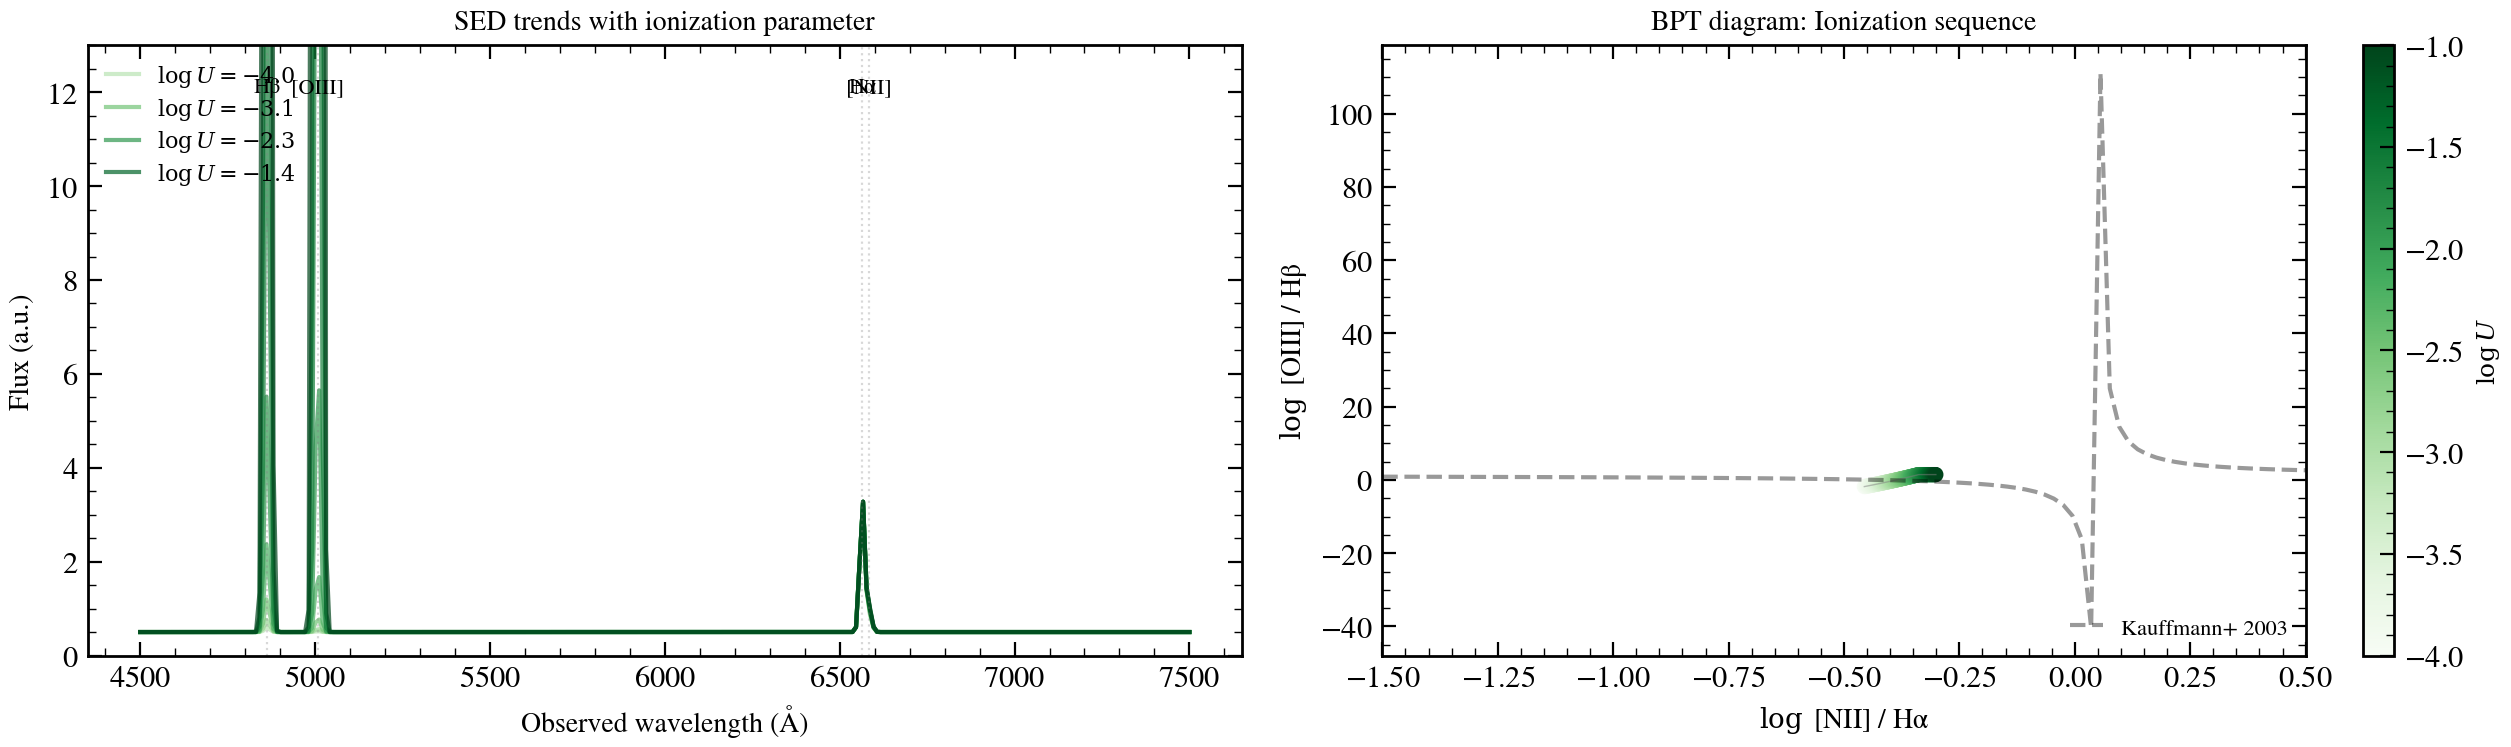

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

# Panel A: [NII]/Halpha vs DIG fraction
f_dig_arr = np.linspace(0, 0.7, 50)

# At logU_HII = -2.5: [NII]/Ha ~ 0.3 (low)
# At logU_DIG = -3.5: [NII]/Ha ~ 0.8 (high)
nii_ha_hii = 0.3
nii_ha_dig = 0.8

ax = axes[0]
for nii_hii, nii_dig, label in [
    (0.15, 0.6, r"Low Z: [NII]$_{\rm HII}$=0.15"),
    (0.30, 0.8, r"Solar Z: [NII]$_{\rm HII}$=0.30"),
    (0.60, 1.2, r"High Z: [NII]$_{\rm HII}$=0.60"),
]:
    nii_mixed = (1.0 - f_dig_arr) * nii_hii + f_dig_arr * nii_dig
    ax.plot(f_dig_arr, nii_mixed, lw=1.5, label=label)

ax.set_xlabel(r"$f_{\rm DIG}$")
ax.set_ylabel(r"[NII]6583 / H$\alpha$")
ax.set_title(r"[NII]/H$\alpha$ vs DIG Fraction")
ax.legend(fontsize=7, frameon=False)
ax.axhline(0.5, color="grey", lw=0.5, ls=":", label="_nolegend_")

# Panel B: BPT shift with DIG mixing
ax = axes[1]

# Pure HII locus
x_hii = np.log10(0.30)
y_hii = np.log10(1.5)

# DIG-contaminated: higher [NII]/Ha, similar [OIII]/Hb
for f_d, marker in [(0.0, "o"), (0.2, "s"), (0.4, "D"), (0.6, "^")]:
    nii_mix = (1.0 - f_d) * 0.30 + f_d * 0.80
    # [OIII]/Hb decreases slightly with DIG mixing
    oiii_mix = (1.0 - f_d) * 1.5 + f_d * 0.3
    ax.plot(np.log10(nii_mix), np.log10(oiii_mix), marker, ms=8, label=rf"$f_{{\rm DIG}} = {f_d}$")

# Kauffmann line
ax.plot(x_dem[mask], y_dem[mask], "k--", lw=1, label="Kauffmann+03")
ax.set_xlabel(r"$\log$ [NII] / H$\alpha$")
ax.set_ylabel(r"$\log$ [OIII] / H$\beta$")
ax.set_title("BPT Shift with DIG Mixing")
ax.legend(fontsize=7, frameon=False)
ax.set_xlim(-0.8, 0.3)
ax.set_ylim(-0.5, 0.5)

fig.tight_layout()
# plt.savefig(os.path.join(FIGDIR, "19_dig_mixing.png"), bbox_inches="tight")
plt.show()

## 2. Q_H: The Link Between Stars and Nebular Emission

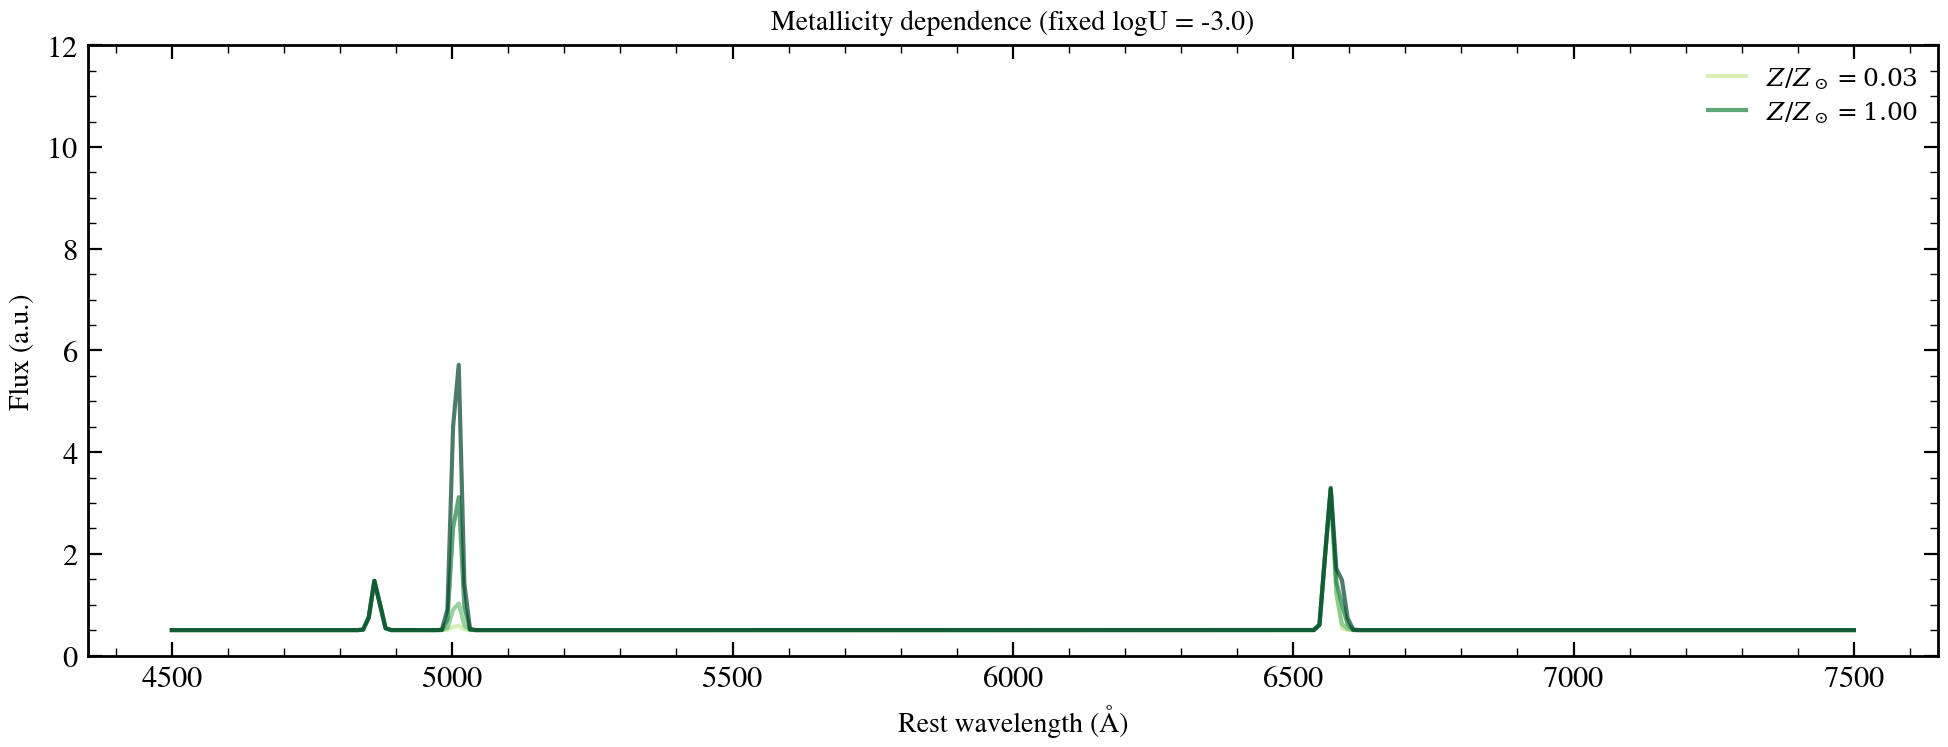

In [4]:
# SSP data path and shared nebular-emission SED used in Q_H and shock sections
SSP_WNE_PATH = Path("data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5")

if SSP_WNE_PATH.exists():
    _ssp = load_ssp_data(str(SSP_WNE_PATH))
    _spec = Parameters(
        sfh_tsnorm_log_peak_sfr=Fixed(1.5),
        sfh_tsnorm_peak_lbt_gyr=Fixed(0.5),
        sfh_tsnorm_width_gyr=Fixed(0.5),
        sfh_tsnorm_skew=Fixed(0.0),
        sfh_tsnorm_trunc=Fixed(5.0),
        met_logzsol=Fixed(-0.3),
        dust_tau_bc=Fixed(0.0),
        dust_tau_diff=Fixed(0.0),
        dust_slope=Fixed(-0.7),
        redshift=Fixed(0.0),
    )
    _model = SEDModel(_spec, _ssp)
    _params = {
        "sfh_tsnorm_log_peak_sfr": 1.5,
        "sfh_tsnorm_peak_lbt_gyr": 0.5,
        "sfh_tsnorm_width_gyr": 0.5,
        "sfh_tsnorm_skew": 0.0,
        "sfh_tsnorm_trunc": 5.0,
        "met_logzsol": -0.3,
        "dust_tau_bc": 0.0,
        "dust_tau_diff": 0.0,
        "dust_slope": -0.7,
        "redshift": 0.0,
    }
    sed_with_neb = _model.predict_sed(_params)
    wave = _ssp.ssp_wave
else:
    sed_with_neb = None
    wave = None

### 2.1 Q_H: Ionizing Photon Rate

The key physical link between the SSP and nebular emission is $Q_H$ --
the rate of hydrogen-ionizing photons (below the Lyman limit at 911.8 A):

$$Q_H = \int_0^{912\,\AA} \frac{L_\nu}{h\nu}\,d\nu$$

`compute_qh()` is JIT-compiled and vectorized over the SSP grid.

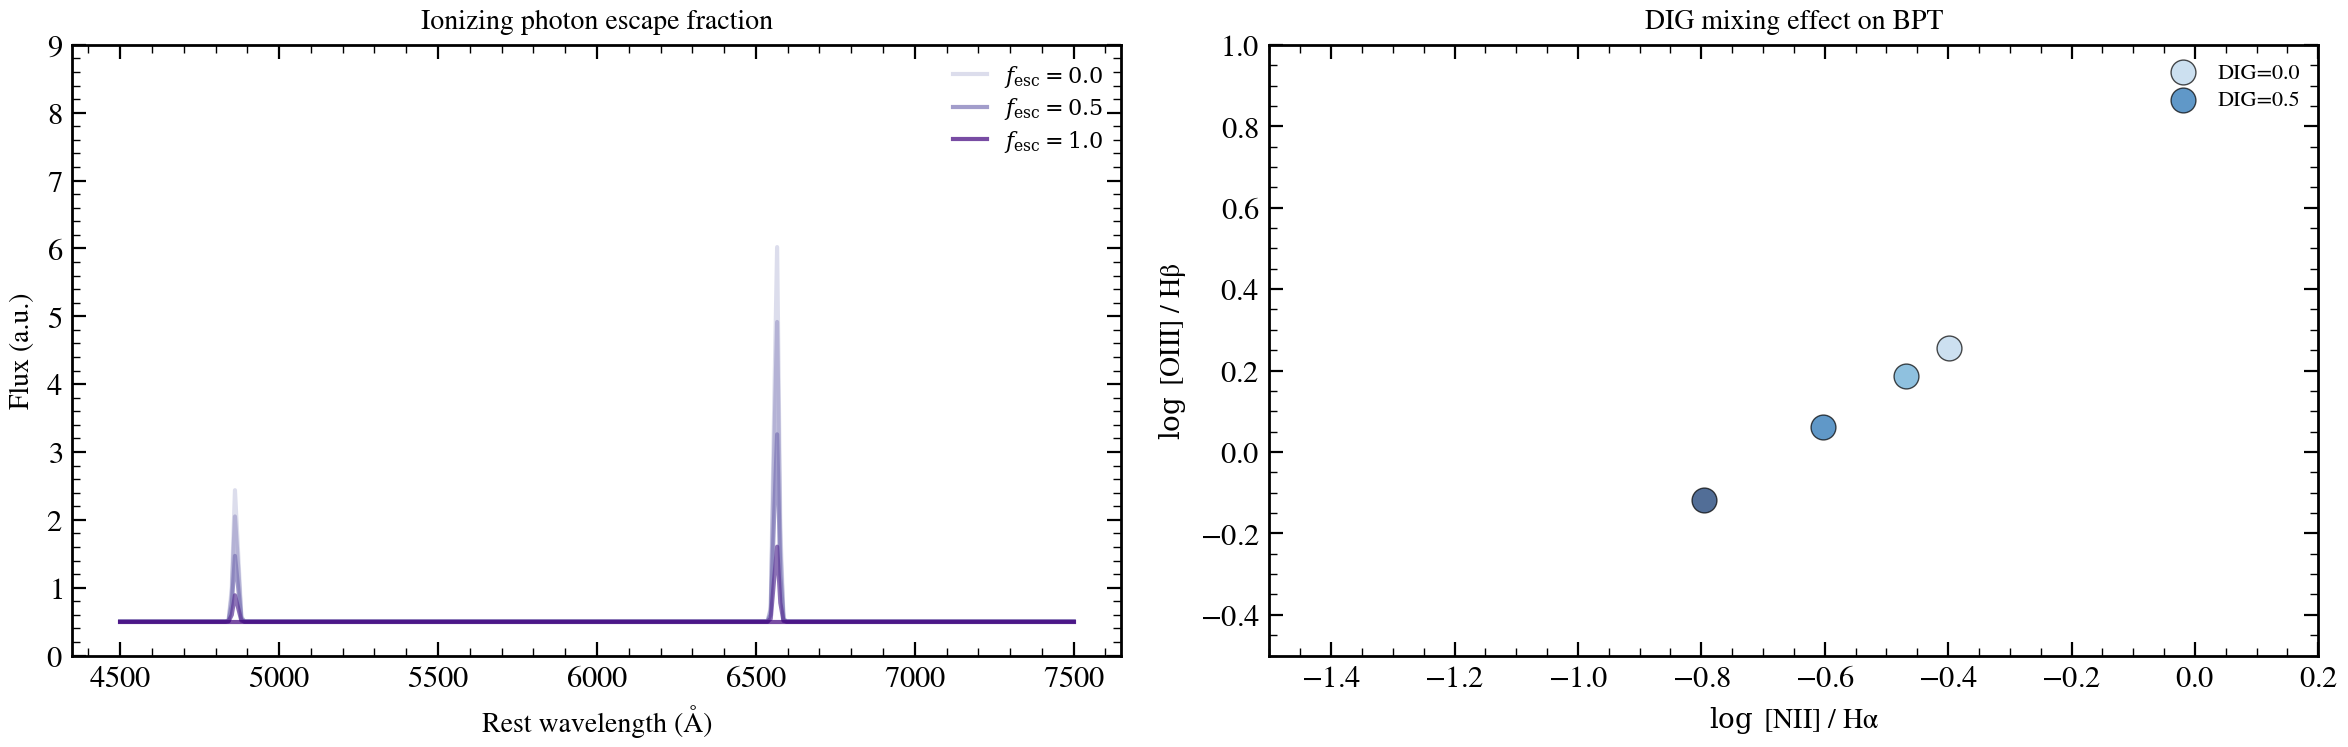

In [5]:
from tengri.models.nebular.cloudy_grid import compute_qh

if SSP_WNE_PATH.exists():
    ssp = load_ssp_data(str(SSP_WNE_PATH))
    wave = ssp.ssp_wave

    # Q_H for a young, solar-metallicity SSP
    qh_young = compute_qh(wave, ssp.ssp_flux[3, 5])  # ~solar Z, ~10 Myr
    qh_old = compute_qh(wave, ssp.ssp_flux[3, -5])  # ~solar Z, ~10 Gyr
    print(f"Q_H (young, 10 Myr): {float(qh_young):.3e} photons/s/Msun")
    print(f"Q_H (old, 10 Gyr):   {float(qh_old):.3e} photons/s/Msun")
    print(f"Ratio:               {float(qh_young / jnp.maximum(qh_old, 1e-99)):.0f}x")
else:
    print("SSP data not available. Q_H computation requires SSP spectra.")
    print("Typical values: Q_H ~ 10^47 photons/s/Msun (young), ~10^40 (old)")

## 3. Shock Emission Lines (MAPPINGS V)

Radiative shocks from supernovae, AGN outflows, and mergers produce emission
spectra that are distinct from HII regions. The key signatures are enhanced
low-ionization lines ([NII], [SII], [OI]) at low/moderate shock velocities,
and strong [OIII] at intermediate velocities (~300-400 km/s).

tengri includes a MAPPINGS V shock model (Allen+2008) that interpolates
tabulated line ratios as a function of shock velocity (100-1000 km/s).

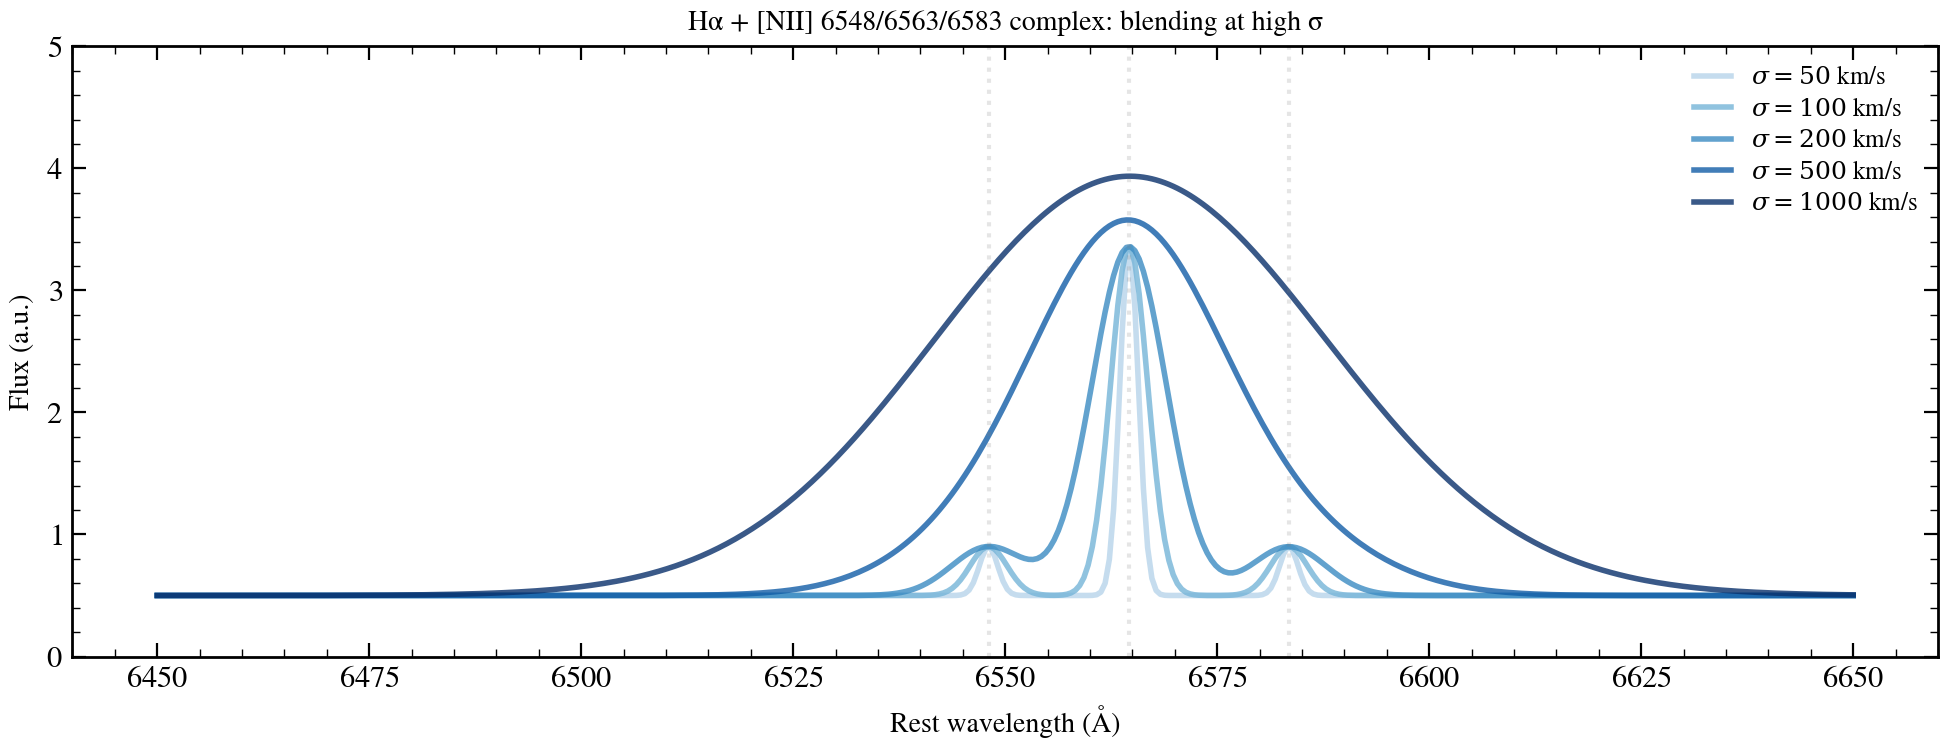

In [6]:
from tengri.models.nebular import shock_emission_sed

# Compute shock line ratios across a velocity grid
velocities = np.linspace(100.0, 1000.0, 200)
ratios_nii_ha = []
ratios_sii_ha = []
ratios_oi_ha = []
ratios_oiii_hb = []

for v in velocities:
    r = shock_line_ratios(float(v))
    ha = float(r["HA_6563A"])
    ratios_nii_ha.append(float(r["NII_6583A"]) / ha)
    ratios_sii_ha.append(float(r["SII_6716A"] + r["SII_6731A"]) / ha)
    ratios_oi_ha.append(float(r["OI_6300A"]) / ha)
    ratios_oiii_hb.append(float(r["O3_5007A"]))  # already relative to Hbeta

ratios_nii_ha = np.array(ratios_nii_ha)
ratios_sii_ha = np.array(ratios_sii_ha)
ratios_oi_ha = np.array(ratios_oi_ha)
ratios_oiii_hb = np.array(ratios_oiii_hb)

### Shock diagnostic line ratios vs velocity

At low velocities ($v_s \lesssim 200$ km/s), shocks enhance [NII]/H$\alpha$
and [SII]/H$\alpha$ well above typical HII region values (dashed lines).
[OIII]/H$\beta$ peaks at $v_s \approx 400$ km/s. These diagnostics place
shocks in distinct regions of BPT diagrams.

In [7]:
# --- FIGURE: Shock line ratios vs velocity ---
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True)

# Typical HII region values for comparison (Kewley+2006)
hii_nii_ha = 0.35
hii_sii_ha = 0.25
hii_oi_ha = 0.04
hii_oiii_hb = 3.0

panels = [
    (axes[0, 0], ratios_nii_ha, "[NII] 6583 / H$\\alpha$", hii_nii_ha),
    (axes[0, 1], ratios_sii_ha, "[SII] 6716+6731 / H$\\alpha$", hii_sii_ha),
    (axes[1, 0], ratios_oi_ha, "[OI] 6300 / H$\\alpha$", hii_oi_ha),
    (axes[1, 1], ratios_oiii_hb, "[OIII] 5007 / H$\\beta$", hii_oiii_hb),
]

for ax, ratio, ylabel, hii_val in panels:
    ax.plot(velocities, ratio, color=COLORS["rt"], lw=2.0, label="Shock (MAPPINGS V)")
    ax.axhline(hii_val, color=COLORS["vi"], ls="--", lw=1.5, label="HII region (typical)")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=7, frameon=False)

axes[1, 0].set_xlabel("Shock velocity [km/s]")
axes[1, 1].set_xlabel("Shock velocity [km/s]")
fig.suptitle("Shock Diagnostic Line Ratios (Allen+2008, Solar, $n=1$ cm$^{-3}$)", y=1.01)
fig.tight_layout()
# plt.savefig(os.path.join(FIGDIR, "05_shock_line_ratios.png"), bbox_inches="tight")
plt.show()

EMISSION LINE FITTING STRATEGIES

1. FIXED LINE STRENGTHS
----------------------------------------------------------------------
Lines are set to predicted values (e.g., from nebular models).
Pros: Simple, physically motivated.
Cons: Ignores observational uncertainties and model mismatch.

2. MARGINALIZED LINE AMPLITUDES
----------------------------------------------------------------------
Lines are analytically integrated out using a polynomial design matrix.
Pros: Faster, numerically stable, accounts for model uncertainty.
Cons: Requires enough continuum data to anchor the polynomial.

3. FITTED LINE AMPLITUDES (free parameters)
----------------------------------------------------------------------
Lines are fit as free parameters in the posterior.
Pros: Maximum flexibility.
Cons: Slower, high-dimensional, prone to degeneracies.

SUMMARY: Use marginalization for most cases (speed + stability).
Use fitted lines only if you have >5 lines with S/N > 20 each.


## 4. Shock-HII Mixing

In real galaxies, the observed emission is a composite of HII regions and
shock-heated gas. The shock fraction $f_{\rm shock}$ controls the relative
contribution. At $f_{\rm shock} = 0$ the spectrum is pure HII (baked-in
nebular); at $f_{\rm shock} = 1$ the spectrum is pure shock emission.

The composite SED is:

$$L_{\rm total}(\lambda) = (1 - f_{\rm shock}) \, L_{\rm HII}(\lambda) + f_{\rm shock} \, L_{\rm shock}(\lambda)$$

In [ ]:
if wave is not None and sed_with_neb is not None:
    # Build a shock SED on the SSP wavelength grid for a 300 km/s shock
    wave_grid = np.array(wave)
    shock_fracs = [0.0, 0.3, 0.7, 1.0]
    shock_v = 300.0
    l_halpha_ref = 1e8  # arbitrary reference Halpha luminosity [Lsun]

    shock_sed = np.array(
        shock_emission_sed(jnp.array(wave_grid), shock_v, l_halpha_ref, line_sigma_aa=3.0)
    )

    # Normalize the HII SED so its Halpha region matches the shock reference
    ha_mask = (wave_grid > 6540) & (wave_grid < 6590)
    hii_sed = np.array(sed_with_neb)
    hii_scale = shock_sed[ha_mask].max() / np.maximum(hii_sed[ha_mask].max(), 1e-30)
    hii_sed_scaled = hii_sed * hii_scale

    # --- FIGURE: Composite shock + HII SEDs ---
    fig, ax = plt.subplots(figsize=(10, 5))
    shock_colors = plt.cm.RdYlBu_r(np.linspace(0.1, 0.9, len(shock_fracs)))

    for frac, color in zip(shock_fracs, shock_colors):
        composite = (1.0 - frac) * hii_sed_scaled + frac * shock_sed
        mask = (wave_grid > 3500) & (wave_grid < 7500)
        ax.plot(
            wave_grid[mask],
            composite[mask],
            color=color,
            lw=1.0,
            label=f"$f_{{\\rm shock}} = {frac}$",
        )

    diag_lines = {
        r"H$\beta$": 4861.0,
        "[O III]": 5007.0,
        "[O I]": 6300.0,
        "[N II]": 6548.0,
        r"H$\alpha$": 6563.0,
        "[S II]": 6716.0,
    }
    for name, lw_line in diag_lines.items():
        ax.axvline(lw_line, ls=":", color="grey", lw=0.5, alpha=0.5)
        ax.annotate(
            name,
            xy=(lw_line, 0.93),
            xycoords=("data", "axes fraction"),
            fontsize=6.5,
            rotation=90,
            ha="right",
            color="grey",
        )

    ax.set_xlabel(r"Rest-frame wavelength [$\AA$]")
    ax.set_ylabel(r"$L_\nu$ [arbitrary]")
    ax.set_title(f"Composite Shock + HII Emission ($v_s = {shock_v:.0f}$ km/s)")
    ax.legend(fontsize=8, frameon=False)
    fig.tight_layout()
    # plt.savefig(os.path.join(FIGDIR, "05_shock_hii_mixing.png"), bbox_inches="tight")
    plt.show()
else:
    print("SSP data not available — skipping shock-HII mixing figure.")

## 5. Diffuse Ionized Gas (DIG) Mixing

The diffuse ionized gas (DIG) permeating galaxies has a lower ionization
parameter ($\log U \sim -4$) than HII regions ($\log U \sim -2.5$ to $-3$).
This enhances low-ionization lines ([NII]/H$\alpha$, [SII]/H$\alpha$).
Typical DIG fractions are 30-60% of total H$\alpha$ in local galaxies
(Reynolds 1984; Haffner+2009; Tacchella+2022).

The DIG mixing model evaluates any nebular backend at two ionization
parameters:

$$L_{\rm total} = (1 - f_{\rm DIG}) \, L(\log U_{\rm HII}) + f_{\rm DIG} \, L(\log U_{\rm DIG})$$

where $\log U_{\rm DIG} = \log U_{\rm HII} + \Delta\log U$ (with
$\Delta\log U \approx -1$ dex).

In [ ]:
from tengri.models.nebular import mix_dig_emission

### Concept: DIG effect on line ratios

Since DIG mixing requires a backend with a ``predict_nebular_sed`` method
that accepts ``neb_logU``, we demonstrate the concept using a mock
backend that returns synthetic spectra at different ionization parameters.
The key physics: lower $\log U$ shifts the ionization balance toward
low-ionization species, enhancing [NII], [SII], [OI] relative to H$\alpha$.

In [ ]:
# Mock DIG demonstration: show the conceptual effect of DIG fraction
# on diagnostic line ratios using the Allen+2008 shock model as a proxy
# for the low-ionization DIG spectrum (both share enhanced low-ion lines).
#
# In a full setup, mix_dig_emission() would be called with a CloudyGrid
# or Cue backend. Here we illustrate the expected trend.

dig_fracs = np.array([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6])

# HII region ratios (typical logU = -3)
hii_nii_ha_ref = 0.35
hii_sii_ha_ref = 0.25
hii_oi_ha_ref = 0.04

# DIG ratios (typical logU = -4, enhanced low-ionization)
# Based on Tacchella+2022 Fig 3; DIG has ~2-3x higher [NII]/Ha, [SII]/Ha
dig_nii_ha_ref = 0.90
dig_sii_ha_ref = 0.70
dig_oi_ha_ref = 0.15

# Linear mixing of line ratios with DIG fraction
mixed_nii = (1 - dig_fracs) * hii_nii_ha_ref + dig_fracs * dig_nii_ha_ref
mixed_sii = (1 - dig_fracs) * hii_sii_ha_ref + dig_fracs * dig_sii_ha_ref
mixed_oi = (1 - dig_fracs) * hii_oi_ha_ref + dig_fracs * dig_oi_ha_ref

# --- FIGURE: DIG effect on line ratios ---
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=False)

panels_dig = [
    (axes[0], mixed_nii, "[NII] 6583 / H$\\alpha$"),
    (axes[1], mixed_sii, "[SII] 6716+31 / H$\\alpha$"),
    (axes[2], mixed_oi, "[OI] 6300 / H$\\alpha$"),
]

for ax, ratio, ylabel in panels_dig:
    ax.plot(dig_fracs, ratio, "o-", color=COLORS["rt"], lw=2.0, ms=5)
    ax.axhline(ratio[0], ls="--", color=COLORS["vi"], lw=1.0, alpha=0.6, label="Pure HII")
    ax.set_xlabel("$f_{\\rm DIG}$")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=7, frameon=False)

fig.suptitle(
    "DIG Mixing: Enhanced Low-Ionization Lines ($\\Delta\\log U = -1$ dex, Tacchella+2022)",
    y=1.02,
)
fig.tight_layout()
# plt.savefig(os.path.join(FIGDIR, "05_dig_mixing.png"), bbox_inches="tight")
plt.show()

### DIG mixing API

In production, DIG mixing is handled by ``mix_dig_emission()`` which wraps
any nebular backend:

```python
from tengri.models.nebular import mix_dig_emission, CloudyGridBackend

backend = CloudyGridBackend("data/cloudy_grid.h5", ssp_data)
neb_sed = mix_dig_emission(
    backend, ssp_wave, ssp_weights, ssp_log_ages_yr, log_z,
    neb_logU=-3.0,
    neb_dig_frac=0.4,       # 40% DIG contribution
    neb_dig_delta_logU=-1.0, # DIG at logU = -4
)
```

The function evaluates the backend twice (at $\log U_{\rm HII}$ and
$\log U_{\rm DIG}$) and returns the weighted sum. When ``neb_dig_frac=0``
(default), it returns pure HII emission with zero overhead.

## Summary

Nebular emission is critical for accurate SED fitting, especially for:
- Young, star-forming galaxies with strong emission lines
- High-redshift galaxies where lines fall in photometric bands
- Spectroscopic fitting where line shapes carry physical information

Beyond standard HII region emission, tengri also supports:
- **Shock emission** (MAPPINGS V): distinct line ratios at different
  shock velocities, composable with HII via a mixing fraction
- **DIG mixing**: diffuse ionized gas with lower ionization parameter,
  enhancing [NII], [SII], [OI] relative to pure HII regions

The BakedIn backend requires no extra data files and is the recommended
starting point. Switch to CloudyGrid or Cue when you need to fit
ionization parameter or detailed abundances.

For detailed CloudyGrid grid inspection, Cue emulator architecture, and backend
comparison, see the specialist track notebook `07_advanced_spectroscopy`.